<a href="https://colab.research.google.com/github/ChandanGurjar/Exploratory-Data-Analysis-EDA-ML-Models/blob/main/Regression-Projects/Housing_Price_Prediction_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### importing the essential libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
sns.set()

#### Loading the data

In [ ]:
raw_data=pd.read_csv('housing_california.csv')
raw_data.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# info() to get the information about the data

raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
# counting the null values
raw_data.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


##### There are 207 districts are missing total_bedrooms

##### The ocean_proximity is object type and we can see it's a categorical variable so we use value_counts() function to check  how many districts belong to each category by using the value_counts() method:

In [ ]:
raw_data['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### Describe() method to check the summary of numerical attributes

In [ ]:
raw_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


 Another way to get the feel of the type of data we are dealing with we took the help of histogram to plot a histogram for each numrical attribute
 We use the hist() method on the whole dataset and it will plot histogram for each numerical attribute

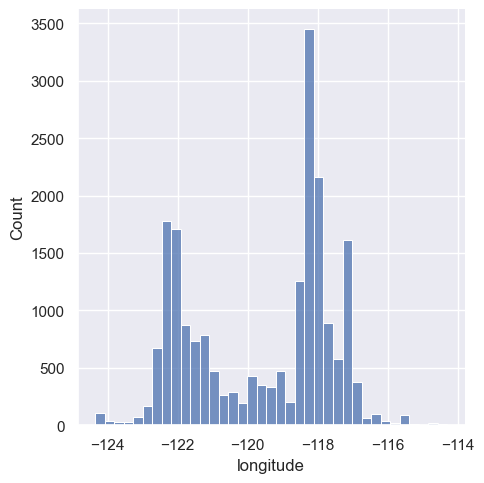

In [ ]:
sns.displot(raw_data['longitude'])

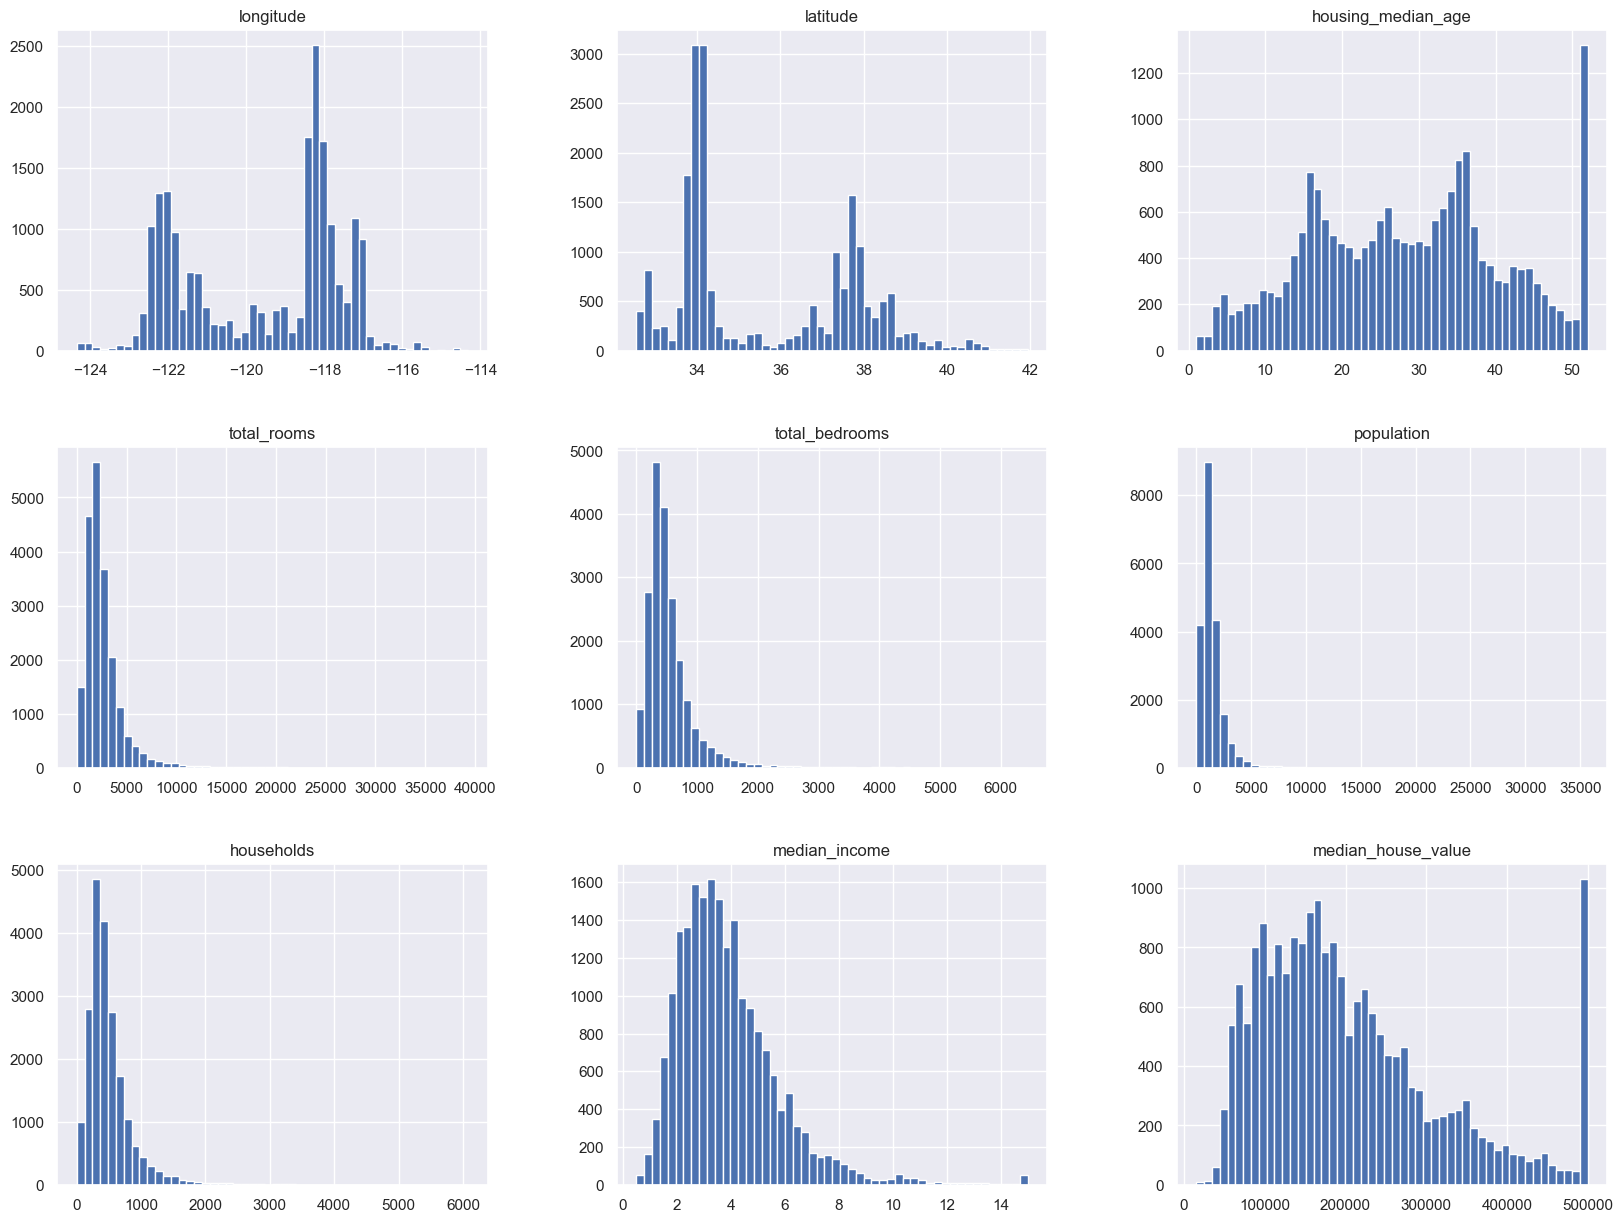

In [ ]:
raw_data.hist(bins=50, figsize=(20,15))
plt.show()

### We notice a few things in these histograms
1. first, the median income attribute does not look like it is expressed in US dollors(USD) ,the data has been scaled and capped at 15 for higher median incomes,and 0.5 for lower median incomes.3 means($30,000)
2. The housing median age and median house value are also capped.
3. We can see many histograms are tall heavy:they extend much farther to the right of the median than to the left .it make it a bit harder for machine learning algorithms to detect patterns .so we will try transforming these attributes later on to have more bell shaped-distributions(normal distributions) which is easy to work with.


### Creating a test Set
#### we are taking 20 % of the dataset for testing set


In [ ]:
# spliting the datasets into train and test set

from sklearn.model_selection import train_test_split

train_set,test_set=train_test_split(raw_data,test_size=0.2,random_state=42)

 Median income seems a very important attribute to predict median housing prices.so to ensure that the test set representative of various categories of incomes in the whole dataset if we look at the median income histogram more closely : nost median income values are clustered around 1.5 to 6(i.e.,$15,000-$60,000),so we use the pd.cut() function to create an income category attribute with 5 categories(labeled from 1 to 5):category 1 ranges from 0 to 1.5(i.e.,less than $15000)category 2 from 1.5 to 3 and so on:

In [ ]:
# pd.cut() method to categorize the median_income into different categories
raw_data['income_cat']=pd.cut(raw_data['median_income'],
                              bins=[0.,1.5,3.0,4.5,6.,np.inf],
                              labels=[1,2,3,4,5])

<Axes: >

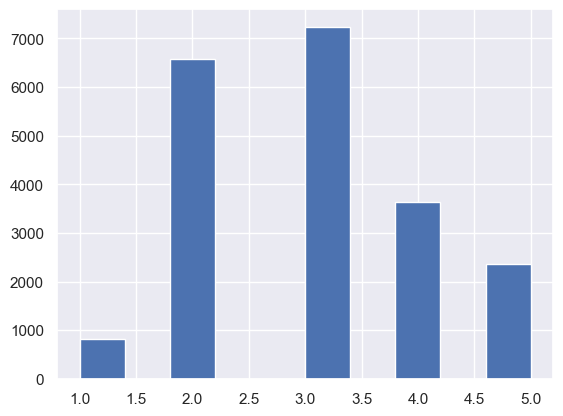

In [ ]:
raw_data['income_cat'].hist()

##### Doing stratified sampling based on the income category we had created using the Scikit-Learn's StratifiedShuffleSplit class:

In [ ]:
# stratified sampling based on the income categories

from sklearn.model_selection import StratifiedShuffleSplit
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index,test_index in split.split(raw_data,raw_data['income_cat']):
    strat_train_set=raw_data.loc[train_index]
    strat_test_set=raw_data.loc[test_index]

In [ ]:
# income category proportions in the test set
strat_test_set['income_cat'].value_counts()/len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

##### Now since we have created test and train set based on stratified sampling distribution based on the median income we will remove the income_cat attribute so the data is back to its original state:

In [ ]:
# now removing the income_cat column
for set_ in (strat_train_set,strat_test_set):
    set_.drop("income_cat",axis=1,inplace=True)

In [ ]:
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN


##### Now we will put the test set aside and only explore the training set. we have created a copy of the training set so that we can work with copy set without harming the original training set

In [ ]:
# making a copy of strat_train_set

housing=strat_train_set.copy()

#### Visualizing Geographical Data
Since there is geographical information(latitude and longitude),we created a scatterplot of all districts to visualize the data and set the alpha =0.1 makes it easier to visualize the places where there is high density of data points

Text(0, 0.5, 'latitude')

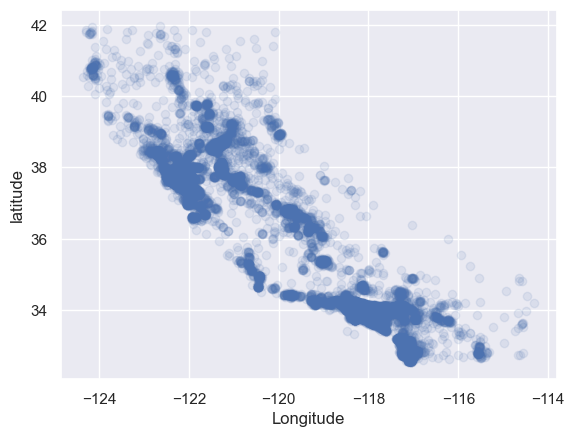

In [ ]:
# ploting
plt.scatter(housing['longitude'],housing['latitude'],alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('latitude')


 We can clearly see the high-density areas ,namely the Bay Area SanFranciso(latitude:37.83 N,logitude:122.29 W),
 Los Angeles(Latitude:34.05 N,Longitude:118.24 W)
 and San Diego(Latitude:32.72 N,longitude:117.16 W),
 plus a long line of fairl high density in the
 Central Valley(Latitude:37 N,longitue: 120.3 W),
 in particular around Sacramento(latitude:38.58 N,longitude:121.49 W),
 and Fresno(latitude:36.74 N,longitude:119.79 W)

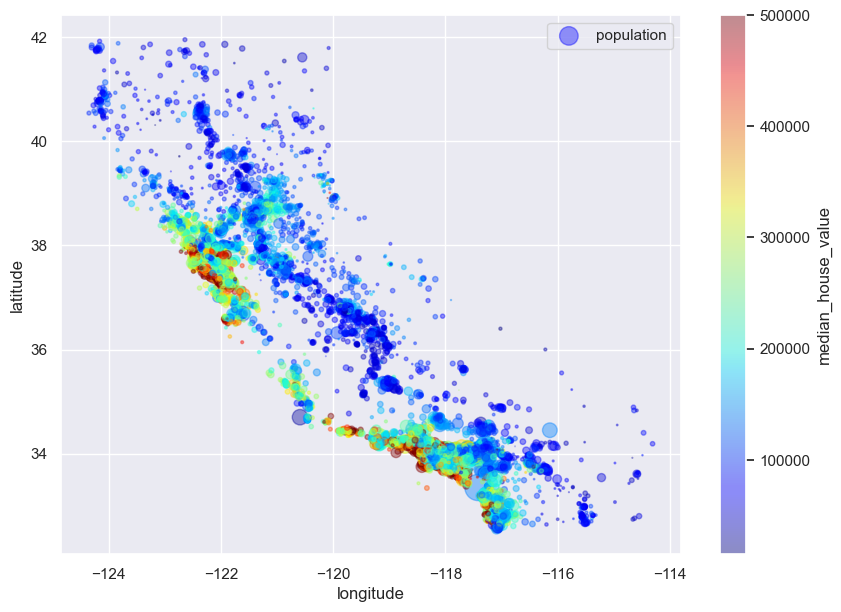

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
 s=housing["population"]/100, label="population", figsize=(10,7),
 c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
 )
plt.legend()

![california-lat-long-map.jpg](attachment:7ddbfc39-ebbc-4315-bc9d-18bff529fb8e.jpg)

This image tell us that the housing prices are very related to the location (e.g, close to the ocean) and to the population density,as we probably knew already. the ocean-proximity attribute may be useful,although in Northern California the housing prices in coastal districts are not too high,so it is not a simple rule.


#### Looking for Correlations
since our dataset is not too large ,we can easily compute the standard correlation coefficient(also called Pearson's r) between every pair of attributes using the corr() method:

Now let’s look at how much each attribute correlates with the median house value:

In [ ]:
# dropping the ocean_proximity column
housing_without_ocean_proximity=housing.drop(['ocean_proximity'],axis=1)
housing_without_ocean_proximity.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0


In [ ]:
corr_matrix=housing_without_ocean_proximity.corr()

In [ ]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

1. The correlation coefficient ranges from –1 to 1. When it is close to 1, it means that there is a strong positive correlation; for example,we can see that the median house value tends to go up when the median income goes up
2. When the coefficient is close to –1, it means that there is a strong negative correlation; we can see a small negative correlation between the latitude and the median house value (i.e., prices have a slight tendency to go down when you go north).
3. coefficients close to zero mean that there is no linear correlation.

#### Ploting the correlation
let's check the correlation between attributes using the pandas scatter_matrix function which will plots every numerical attribute against every other numerical attribute .Since there are now 11 numerical attributes we will get 11^2=121 plots ,which would not fit on a page ,so let's just focus on a few promising attributes that seem most correlated with the median housing value

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

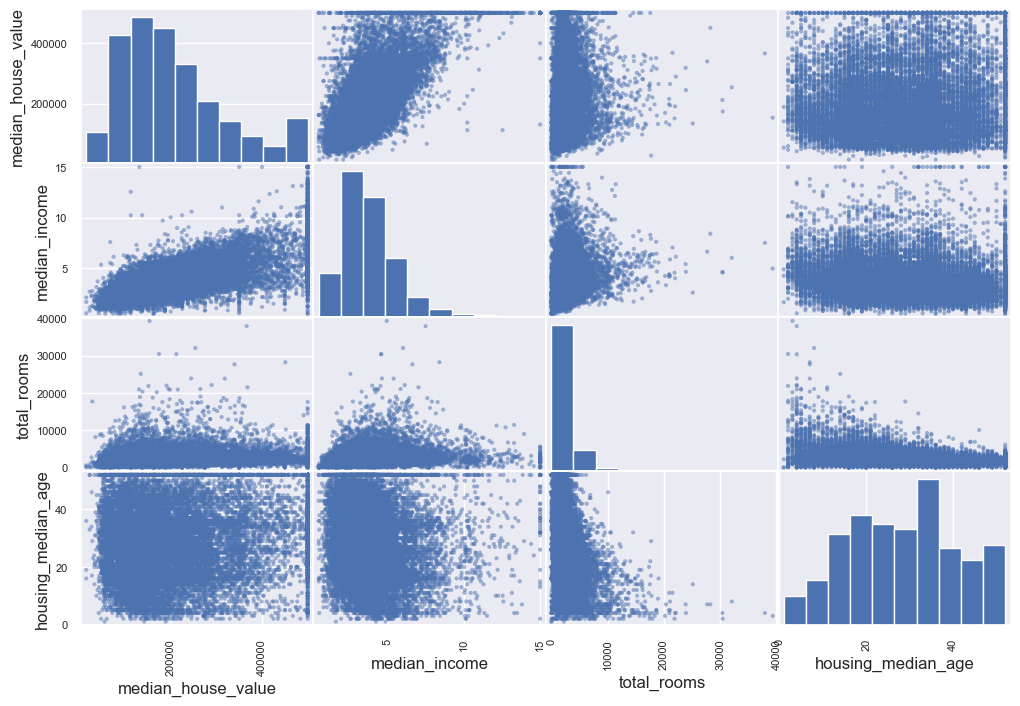

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

 The most promising attribute to predict the median house value is the median
 income, so let’s zoom in on their correlation scatterplot

<Axes: xlabel='median_income', ylabel='median_house_value'>

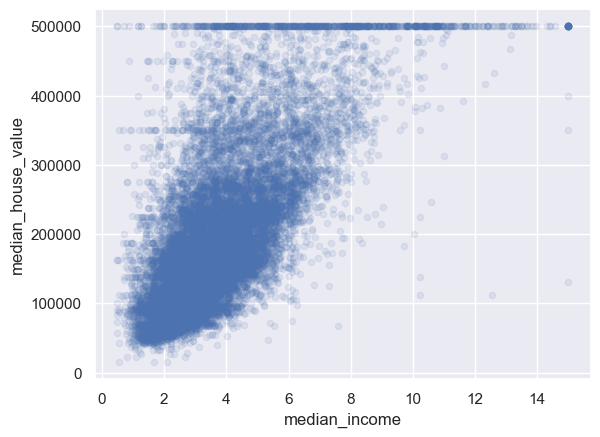

In [ ]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
 alpha=0.1)

####  This plot reveals a few things:
1. we can see the correlation is indeed very strong; you canmclearly see the upward trend and the points are not too dispersed.
2. the price cap that we noticed earlier is clearly visible as a horizontal line at ($500,000) ,But this plot reveals other less obvious straight lines, horizontal line around ($450,000),another around ($350,000), perhaps one around ($280,000), and a few more below that.

we may want to try removing the corresponding districts to prevent our algorithms
from learning to reproduce these data quirks.

#### Attributes Combinations
1. the total number of rooms in a district is not very useful if you don’t know how many households there are. What we can really want is the number of rooms per household.
2. Similarly, the total number of bedrooms by itself is not very useful: but we probably want to compare it to the number of rooms.
3. And the population per household also seems like an interesting attribute combination to look at.
Let’s create these new attributes:

In [ ]:
#creating new attributes
housing['rooms_per_household']=housing['total_rooms']/housing['households']
housing['bedrooms_per_room']=housing['total_bedrooms']/housing['total_rooms']
housing['population_per_household']=housing['population']/housing['households']


In [ ]:
# making a new copy of  housing
housing_new=housing.copy()


In [ ]:
# droping the ocean proximitty column

housing_new=housing_new.drop(['ocean_proximity'],axis=1)

In [ ]:
housing_new.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,5.485836,0.205784,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,6.927083,0.160714,2.623698
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,5.393333,0.191595,2.223333
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,3.886128,0.276505,1.859213
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,6.096552,0.182692,3.167241


In [ ]:
# using the corr_coefficient

corr_matrix=housing_new.corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

#####  The new bedrooms_per_room attribute is much more correlated with the median house value than the total number of rooms or bedrooms. Apparently houses with a lower bedroom/room ratio tend to be more expensive. The number of rooms per household is also more informative than the total number of rooms in a district—obviously the larger the houses, the more expensive they are.

### Prepare the Data for Machine Learing Algorithms
Instead of just doing this manually,It's better to write functions to do that, for several good reasons:
1. This will allow us to reproduce these transformations easily on any dataset (e.g.,the next time we get a fresh dataset).
2. We will gradually build a library of transformation functions that we can reuse in future projects.
3. we can use these functions in our live system to transform the new data before
 feeding it to our algorithms.
4. This will make it possible for us to easily try various transformations and see which combination of transformations works best.

let’s revert to a clean training set (by copying strat_train_set once again), and let’s separate the predictors and the labels since we don’t necessarily want to apply the same transformations to the predictors and the target values.

In [ ]:
# creating a new copy droping the our predict attribute
housing=strat_train_set.drop('median_house_value',axis=1)
# labels
housing_labels=strat_train_set['median_house_value'].copy()

In [ ]:
housing.reset_index(drop=True)
housing.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN


In [ ]:
housing_labels.reset_index(drop=True)
housing_labels.head(5)

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
Name: median_house_value, dtype: float64

### Data Cleaning
Most Machine Learning algorithms cannot work with missing features,so let’s create a few functions to take care of them. we noticed earlier that the total_bedrooms attribute has some missing values, so let’s fix this.
We have three options in this situation:
1. Get rid of the corresponding districts.
2. Get rid of the whole attribute.
3. Set the values to some value (zero, the mean, the median, etc.)

we can accomplish these easily using DataFrame's dropna(),drop(),fillna() methods

We can also to this by using Scikit-Learn,It provides a handy class to take care of missing values: SimpleImputer.

In [ ]:
from sklearn.impute import SimpleImputer

imputer =SimpleImputer(strategy='median')


Since the median can only be computed on numerical attributes, we need to create a copy of the data without the text attribute ocean_proximity:

In [ ]:
housing_num=housing.drop('ocean_proximity',axis=1)

In [ ]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

the imputer has simply calculated the median of each attribute and stored the results in statistics_ instance variable .right now only the total_bedrooms is containing the missing values but we don't know or not sure that there won't be any missing values in near future when the system goes live,so it is safer to apply the imputer to all the numerical attributes.

In [ ]:
# checking the median values of all the numercial attributes stored
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [ ]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

now we can transform the training set by using transform which will replace all the missing values

In [ ]:
X = imputer.transform(housing_num)

The result is a plain NumPy array containing the transformed features. Now to turn it back into a Pandas DataFrame


In [ ]:
housing_tr=pd.DataFrame(X,columns=housing_num.columns)

In [ ]:
housing_tr.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
1,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
3,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
4,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964


In [ ]:
# now we can see that there are no missing values in the training set
housing_tr.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

### Handling Text and Categorical Attributes
Earlier we left out the categorical attribute ocean_proximity because it is a text attribute so we cannot compute its median.

In [ ]:
housing_cat=housing[['ocean_proximity']]
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


let’s convert these categories from text to numbers. For this, we can use Scikit-Learn’s OrdinalEncoder class.

In [ ]:
housing_cat.reset_index(drop=True)

,ocean_proximity
0,INLAND
1,NEAR OCEAN
2,INLAND
3,NEAR OCEAN
4,<1H OCEAN
...,...
16507,<1H OCEAN
16508,INLAND
16509,<1H OCEAN
16510,<1H OCEAN


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder=OrdinalEncoder()


In [ ]:
#housing_cat = np.array(housing_cat).reshape(-1, 1)  # Convert to a 2D array

In [ ]:
# you can either use the fit() or fit_transform() but the later one is faster
housing_cat_encoded=ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

we can get the list of categories using the categories_ instance variable. It is a list containing a 1D array of categories for each categorical attribute (in this case, a list containing a single array since there is just one categorical attribute)

In [ ]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

One issue with this representation is that ML algorithms will assume that two nearby values are more similar than two distant values.This may be fine in some cases (e.g.,for ordered categories such as “bad”, “average”, “good”, “excellent”), but it is obviously not the case for the ocean_proximity column (for example, categories 0 and 4 are clearly more similar than categories 0 and 1). To fix this issue, a common solution is to create one binary attribute per category: one attribute equal to 1 when the category is “<1H OCEAN” (and 0 otherwise), another attribute equal to 1 when the category is “INLAND” (and 0 otherwise), and so on. This is called one-hot encoding, because only one attribute will be equal to 1 (hot), while the others will be 0 (cold).

In [ ]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder=OneHotEncoder()
housing_cat_1hot=cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [ ]:
# covert it to a dense numpy array
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [ ]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

### Custom Transformers
here is a small transformer class that adds the combined attributes we discussed earlier

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
   def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
   def fit(self, X, y=None):
        return self  # nothing else to do
   def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
           bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
           return np.c_[X, rooms_per_household, population_per_household,bedrooms_per_room]
        else:
           return np.c_[X, rooms_per_household, population_per_household]
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

#### Feature Scaling
 One of the most important transformations we need to apply to our data is feature scaling. With few exceptions, Machine Learning algorithms don’t perform well when the input numerical attributes have very different scales. This is the case for the housing data: the total number of rooms ranges from about 6 to 39,320, while the median incomes only range from 0 to 15.scaling the target values is generally not required.

There are two common ways to get all attributes to have the same scale: min-max
scaling and standardization.

Min-max scaling (many people call this normalization) is quite simple: values are
shifted and rescaled so that they end up ranging from 0 to 1. We do this by subtracting the min value and dividing by the max minus the min.

### Transformation Pipelines
using the transformation pipelines to transform the data so that we don't have to write the code again and again scikit -learn provides the pipeline class to help with the such sequence of transformations

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler



num_pipeline=Pipeline([('imputer',SimpleImputer(strategy='median')),
                        ('attribs_adder',CombinedAttributesAdder()),
                       ('std_scaler',StandardScaler()),])
housing_num_tr=num_pipeline.fit_transform(housing_num)

When you call the pipeline’s fit() method, it calls fit_transform() sequentially on all transformers, passing the output of each call as the parameter to the next call, until it reaches the final estimator, for which it just calls the fit() method.

In [ ]:
from sklearn.compose import ColumnTransformer

num_attribs=list(housing_num)
cat_attribs=['ocean_proximity']
full_pipeline=ColumnTransformer([
    ('num',num_pipeline,num_attribs),
    ('cat',OneHotEncoder(),cat_attribs),])
housing_prepared=full_pipeline.fit_transform(housing)

### Select and train a model
We framed the problem,we got the data and explored it, we sampled a training set and a test set, and we wrote transformation pipelines to clean up and prepare our data for Machine Learning algorithms automatically.we are now ready to select and train a Machine Learning model.



###  Training and Evaluating on the Training Set
Let’s first train a Linear Regression model

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(housing_prepared,housing_labels)

LinearRegression()

Let’s try it out on a few instances from the training set:

In [ ]:
# let's try the model on the few instances
some_data=housing.iloc[:5]
some_labels=housing_labels.iloc[:5]

some_data_prepared=full_pipeline.transform(some_data)

In [ ]:
print('Predictions:', lin_reg.predict(some_data_prepared))
print('labels:', list(some_labels))

Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


It works, although the predictions are not exactly accurate (e.g., the first prediction is off by close to 40%!). Let’s measure this regression model’s RMSE on the whole training set using Scikit-Learn’s mean_squared_error function:

In [ ]:
from sklearn.metrics import mean_squared_error
housing_predictions=lin_reg.predict(housing_prepared)
lin_mse=mean_squared_error(housing_labels,housing_predictions)
lin_rmse=np.sqrt(lin_mse)
lin_rmse

np.float64(68627.87390018745)

this is better than nothing but clearly not a great  score most districts’median_housing_values range between 120,000 and 265,000, so a typical prediction error of $68,628 is not very satisfying. This is an example of a model underfitting the training data. When this happens it can mean that the features do not provide enough information to make good predictions, or that the model is not powerful enough.

the main ways to fix underfitting are to select a more powerful model, to feed the training algorithm with better features,or to reduce the constraints on the model. This model is not regularized, so this rules out the last option. We could try to add more features.

Let’s train a DecisionTreeRegressor.This is a powerful model, capable of finding
complex nonlinear relationships in the data.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor()

In [ ]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

the model has badly overfit the data.we don’t want to touch the test set until we are ready to launch a model we are confident about, so we need to use part of the training set for training,and part for model validation.

###  Better Evaluation Using Cross-Validation
so we need to use part of the training set for traing and part for model validation one way to train the decision tree model is to use train_test_split to split the training set into a smaller training set and a validation set ,then train your models against the smaller training set and evaluating them against the validation sets a great alternative is to use scikit-learn's k-fold validation feature. That randomly split the training set into 10 distinct subsets called folds,then it trains and evaluates decision tree model 10 times ,picking a different fold for evaluation every time and training on the other 9 folds.The result is an array containing the 10 evaluation scores:

In [ ]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(tree_reg,housing_prepared,housing_labels,
                       scoring='neg_mean_squared_error',cv=10)
tree_rmse_scores=np.sqrt(-scores)

In [ ]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [ ]:
display_scores(tree_rmse_scores)

Scores: [72325.95893592 69970.35500885 68366.4071268  73483.8439162
 71973.65835462 78216.03181265 68943.0789316  72158.06500262
 68165.05075148 71636.75870823]
Mean: 71523.9208548964
Standard deviation: 2832.1769144273626


Now the Decision Tree doesn’t look as good as it did earlier. In fact, it seems to perform worse than the Linear Regression model! Notice that cross-validation allows ous to get not only an estimate of the performance of our model, but also a measure of how precise this estimate is (i.e., its standard deviation). The Decision Tree has a score of approximately 71,407, generally ±2,439.we would not have this information if we just used one validation set. But cross-validation comes at the cost of training the model several times.

##### let's compute the same scores for the linear Regression model just to be sure

In [ ]:
lin_scores=cross_val_score(lin_reg,housing_prepared,housing_labels,
                           scoring='neg_mean_squared_error',cv=10)
lin_rmse_scores=np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247063
Standard deviation: 2880.3282098180675


so we got the information that the decision tree model is overfitting so badly that it performance is worse than the linear Regression model

### RandomForestRegressor
Random Forests work by training many Decision Trees on random subsets of the features, then averaging out their predictions.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest_reg=RandomForestRegressor()
forest_reg.fit(housing_prepared,housing_labels)

RandomForestRegressor()

In [ ]:
forest_predictions=forest_reg.predict(housing_prepared)

forest_mse=mean_squared_error(housing_labels,forest_predictions)
forest_rmse=np.sqrt(forest_mse)
forest_rmse

np.float64(18619.13626919632)

In [ ]:
forest_scores=cross_val_score(forest_reg,housing_prepared,housing_labels,
                           scoring='neg_mean_squared_error',cv=10)
forest_rmse_scores=np.sqrt(-forest_scores)


In [ ]:
display_scores(forest_rmse_scores)

Scores: [51245.16554395 49252.48180938 46803.2616418  51935.01960533
 47594.95301343 51717.64750725 52749.41381501 49638.55166839
 48585.18182148 53708.85888208]
Mean: 50323.05353081121
Standard deviation: 2172.805829291195


this is much better: Random Forests look very promising. However, note that
the score on the training set is still much lower than on the validation sets, meaning that the model is still overfitting the training set. Possible solutions for overfitting are to simplify the model, constrain it (i.e., regularize it), or get a lot more training data.

we can save every model  experiment with so we can come back easily to any model we want .make sure we save both the hyperparameters and the trained parameters ,as well the cross-validation scores and perhaps the actual predictions as well .this will allow you to easily compare scores across model types ,and compare the types of errors they make .we can easily save scikit-learn moels by using python's pickle module,or using sklearn.externals.joblib,which is more efficient at serializing large numpy arrays:

In [ ]:
import joblib
joblib.dump(lin_reg, "my_model.pkl")


['my_model.pkl']

In [ ]:
# and later
my_model_loaded=joblib.load('my_model.pkl')

### Fine tune the model

#### Grid Search
One way to do that would be to fiddle with the hyperparameters manually ,until you find a great combination of hyperparameter values .This would be very tedious work, and we may not have time to explore many combinations.             Instead we should get scikit-learn's GridSearchCV to search for us.all we need to do is tell it which hyperparameters we want it to experiment with ,and what values to try out and it will evalute all the possible  combinations of hyperparameter values,using cross-validation. for example ,the following code searches for the best combination of hyperparameter values for the RandomForestRegressor:

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid=[
    {'n_estimators':[3,10,30],'max_features':[2,4,6,8]},
    {'bootstrap':[False],'n_estimators':[3,10],'max_features':[2,3,4]},
]

forest_reg=RandomForestRegressor()
grid_search=GridSearchCV(forest_reg,param_grid,cv=5,
                         scoring='neg_mean_squared_error',
                         return_train_score=True)
grid_search.fit(housing_prepared,housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [ ]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

##### since 8 and 30 are the maximum values that were evaluated,we should probably try searching again  with higher values,since the score may continue to improve

In [ ]:
# we can also get the best estimator directly:
grid_search.best_estimator_

RandomForestRegressor(max_features=6, n_estimators=30)

In [ ]:
# course the evluation scores are also available:

cvres=grid_search.cv_results_
for mean_score,params in zip(cvres['mean_test_score'],cvres['params']):
    print(np.sqrt(-mean_score),params)

63986.15471334449 {'max_features': 2, 'n_estimators': 3}
55619.56300851399 {'max_features': 2, 'n_estimators': 10}
52494.24759164513 {'max_features': 2, 'n_estimators': 30}
60344.07352896225 {'max_features': 4, 'n_estimators': 3}
52913.376184425484 {'max_features': 4, 'n_estimators': 10}
50477.522493343036 {'max_features': 4, 'n_estimators': 30}
59729.606869079194 {'max_features': 6, 'n_estimators': 3}
51973.833766082396 {'max_features': 6, 'n_estimators': 10}
49897.43104824873 {'max_features': 6, 'n_estimators': 30}
58057.71855107904 {'max_features': 8, 'n_estimators': 3}
51752.253871291745 {'max_features': 8, 'n_estimators': 10}
50214.15877710033 {'max_features': 8, 'n_estimators': 30}
62870.446616111876 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54489.488291058085 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
59409.7077089895 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52531.396652870986 {'bootstrap': False, 'max_features': 3, 'n_estimato

In this example, we obtain the best solution by setting the max_features hyperparameter to 8, and the n_estimators hyperparameter to 30. The RMSE score for this combination is 49,682, which is slightly better than the score you got earlier using the default hyperparameter values (which was 50,182).we have
successfully fine-tuned your best model by a little.

### Randomized Search
The grid search approach is fine when we are exploring relatively few combinations, like in the previous example, but when the hyperparameter search space is large, it is often preferable to use RandomizedSearchCV instead. This class can be used in much the same way as the GridSearchCV class, but instead of trying out all possible combinations, it evaluates a given number of random combinations by selecting a random value for each hyperparameter at every iteration. This approach has two main benefits:
1. If we let the randomized search run for, say, 1,000 iterations, this approach will explore 1,000 different values for each hyperparameter (instead of just a few values per hyperparameter with the grid search approach)
2. we have more control over the computing budget we want to allocate to hyper
parameter search, simply by setting the number of iterations.

###  Analyze the Best Models and Their Errors
we will often gain good insights on the problem by inspecting the best models. For example, the RandomForestRegressor can indicate the relative importance of each attribute for making accurate predictions.

In [ ]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([8.31381356e-02, 7.27427766e-02, 4.33467557e-02, 1.66030359e-02,
       1.61624436e-02, 1.71172284e-02, 1.62848651e-02, 3.03649025e-01,
       6.91857937e-02, 1.03030293e-01, 8.81650029e-02, 1.68729064e-02,
       1.41526921e-01, 6.30553187e-05, 5.88202941e-03, 6.22973275e-03])

In [ ]:
# Let’s display these importance scores next to their corresponding attribute names
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.30364902469688737), 'median_income'),
 (np.float64(0.14152692059040833), 'INLAND'),
 (np.float64(0.10303029325773577), 'pop_per_hhold'),
 (np.float64(0.08816500291526656), 'bedrooms_per_room'),
 (np.float64(0.08313813564455894), 'longitude'),
 (np.float64(0.07274277657663508), 'latitude'),
 (np.float64(0.06918579373940134), 'rooms_per_hhold'),
 (np.float64(0.043346755712163176), 'housing_median_age'),
 (np.float64(0.01711722842689762), 'population'),
 (np.float64(0.016872906397910406), '<1H OCEAN'),
 (np.float64(0.016603035864418733), 'total_rooms'),
 (np.float64(0.016284865147206812), 'households'),
 (np.float64(0.01616244355809435), 'total_bedrooms'),
 (np.float64(0.006229732746765087), 'NEAR OCEAN'),
 (np.float64(0.005882029406988814), 'NEAR BAY'),
 (np.float64(6.30553186616306e-05), 'ISLAND')]

#### Evaluate your System on the test Set

In [ ]:
final_model=grid_search.best_estimator_
X_test=strat_test_set.drop('median_house_value',axis=1)
y_test=strat_test_set['median_house_value'].copy()
X_test_prepared=full_pipeline.transform(X_test)
final_predictions=final_model.predict(X_test_prepared)


In [ ]:
final_mse=mean_squared_error(y_test,final_predictions)
final_rmse=np.sqrt(final_mse)
final_rmse

np.float64(47887.83634717442)

In [ ]:
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
loc=squared_errors.mean(),
scale=stats.sem(squared_errors)))

array([45889.32125971, 49806.22385155])

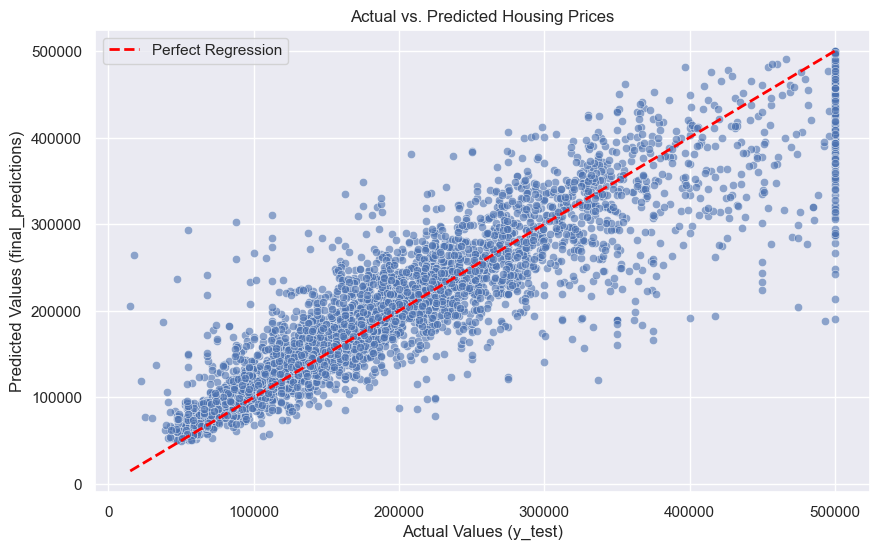

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'y_test' contains the actual values and 'final_predictions' contains the predicted values from your model.

# Create a scatter plot of the actual vs. predicted values.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=final_predictions, alpha=0.6)

# Create a line of perfect regression (y=x)
# This line shows where the predicted values would be if they were exactly equal to the actual values.
line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(line, line, color='red', linestyle='--', linewidth=2, label='Perfect Regression')

# Add labels and a title to the plot
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (final_predictions)")
plt.title("Actual vs. Predicted Housing Prices")
plt.legend()

# Show the plot
plt.show()